# 07 — Prediction & Final Report

## Putting it all to use

This is where everything comes together: we use the trained model to
forecast **actual future sales** beyond the end of our dataset, and
summarize the whole project's findings in one place.

## Why forecasting the future is different from testing

In Notebook 05/06, we evaluated the model on a **test set that already had
real historical data** - so lag/rolling features could be computed directly
from real numbers. For genuinely future dates, day 2 of the forecast needs
"yesterday's revenue" (Lag_1) - but that's day 1's *prediction*, not a real
number. `predict.forecast_future()` handles this by predicting one day at a
time and feeding each prediction back in as if it were real history before
predicting the next day (see its docstring for the full reasoning). This is
why forecasts further into the future are less reliable - errors can
compound step by step.

In [1]:
import sys
sys.path.append("../src")

import pickle
import pandas as pd
import matplotlib.pyplot as plt

from ecommerce_sales_analysis.features import build_daily_revenue
from ecommerce_sales_analysis.predict import forecast_future

cleaned = pd.read_csv('../data/processed/cleaned_retail.csv', parse_dates=['InvoiceDate'])
daily = build_daily_revenue(cleaned)

with open('../data/processed/trained_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)

results = pd.read_csv('../data/processed/model_results.csv', index_col=0)
best_model_name = results.index[0]
if best_model_name.startswith('Baseline'):
    best_model_name = results.index[1]
best_model = fitted_models[best_model_name]

print(f"Forecasting with: {best_model_name}")
print(f"Historical data ends: {daily.index.max().date()}")

Forecasting with: RandomForest
Historical data ends: 2011-12-09


In [2]:
FORECAST_DAYS = 14
forecast = forecast_future(best_model, daily, n_days=FORECAST_DAYS)
forecast

Note: forecasting 14 days ahead using recursive lag features. Accuracy typically degrades the further out you predict, since each day's forecast is partly built on the previous day's forecast rather than real data. Treat predictions beyond ~7 days as directional, not precise.


2011-12-10      631.144569
2011-12-11    32731.166098
2011-12-12    43990.080822
2011-12-13    44590.538191
2011-12-14    47034.768358
2011-12-15    44590.926109
2011-12-16    39739.419343
2011-12-17       25.290569
2011-12-18    26823.193259
2011-12-19    42617.490622
2011-12-20    43853.829727
2011-12-21    43327.210118
2011-12-22    43624.016210
2011-12-23    41222.494751
Freq: D, Name: PredictedRevenue, dtype: float64

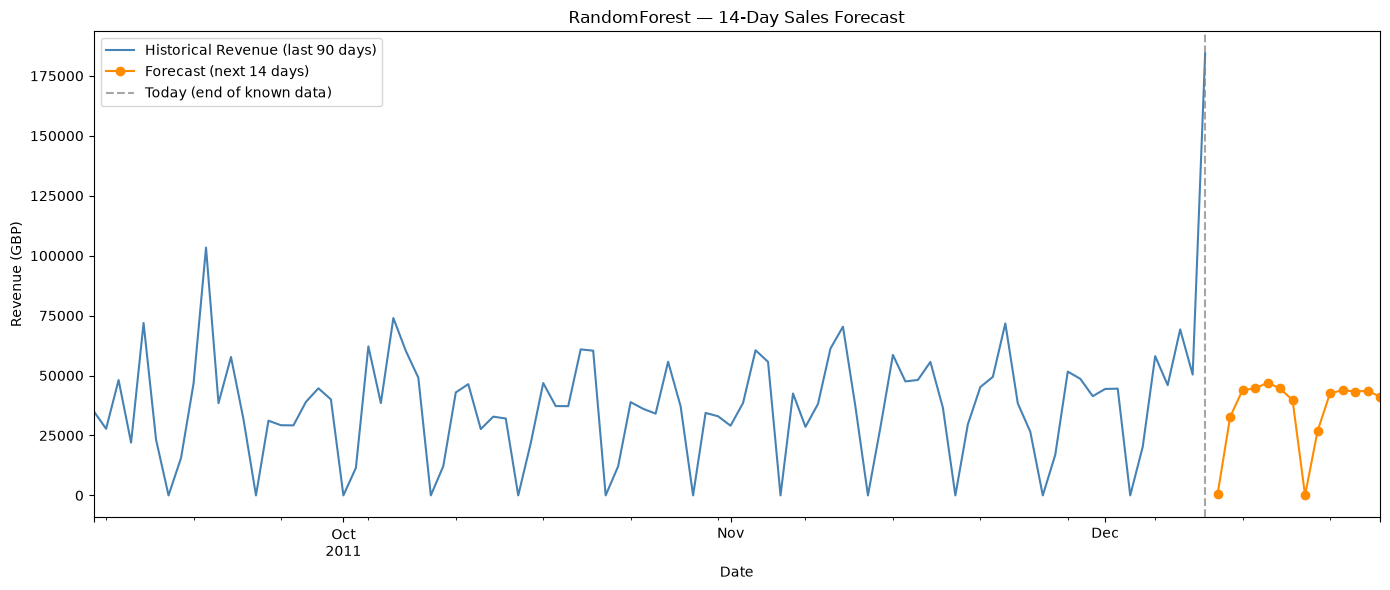

In [3]:
# Plot the last 90 days of real history alongside the forecast, so the
# forecast's scale and pattern can be visually sanity-checked against
# recent real behavior.
fig, ax = plt.subplots(figsize=(14, 6))

recent_history = daily['Revenue'].tail(90)
recent_history.plot(ax=ax, label='Historical Revenue (last 90 days)', color='steelblue')
forecast.plot(ax=ax, label=f'Forecast (next {FORECAST_DAYS} days)', color='darkorange', marker='o')

ax.axvline(daily.index.max(), color='gray', linestyle='--', alpha=0.7, label='Today (end of known data)')
ax.set_title(f'{best_model_name} — {FORECAST_DAYS}-Day Sales Forecast')
ax.set_ylabel('Revenue (GBP)')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
print(f"Total forecasted revenue over next {FORECAST_DAYS} days: GBP {forecast.sum():,.2f}")
print(f"Average forecasted daily revenue: GBP {forecast.mean():,.2f}")
print(f"Recent actual average (last 30 days of history): GBP {daily['Revenue'].tail(30).mean():,.2f}")

Total forecasted revenue over next 14 days: GBP 494,801.57
Average forecasted daily revenue: GBP 35,342.97
Recent actual average (last 30 days of history): GBP 43,968.36


In [5]:
# Save the forecast as the project's final deliverable artifact
from pathlib import Path
forecast_path = Path('../reports/sales_forecast.csv')
forecast.to_frame().to_csv(forecast_path)
print(f"Saved forecast to {forecast_path}")

Saved forecast to ..\reports\sales_forecast.csv


---

# Final Report

## Objective

Build a full pipeline (load → clean → EDA → feature engineering → ML →
evaluation → prediction) on real e-commerce transaction data, predicting
aggregate daily sales revenue via time-series forecasting - with every step
explained, not just implemented.

## Dataset

**Online Retail II** (UCI ML Repository) - real transactions from a UK-based
online gift-ware retailer, 01/12/2009 to 09/12/2011.
- Raw: 1,067,371 transaction line items
- After cleaning: 779,425 valid sales (26.98% removed: cancellations, missing
  customer IDs, invalid quantity/price, duplicates)
- Aggregated: 739 days of daily revenue → 709 model-ready rows after feature
  engineering warm-up

## Key EDA Findings

- **Market concentration:** UK accounts for 82.8% of total revenue.
- **Customer concentration:** top 20% of customers generate 77.2% of revenue
  (classic 80/20 pattern) - a handful of large accounts matter a lot.
- **Seasonality:** clear month-of-year pattern consistent with a gift-ware
  retailer (Nov/Dec surge); near-zero Saturday activity.
- **Outliers:** revenue per line item has a long right tail (99th percentile
  ~£204, max ~£168K) from large wholesale orders - legitimate sales, not
  data errors, and smoothed out naturally by daily aggregation.

## Feature Engineering

Transactions were aggregated to a gap-free daily revenue series, then
enriched with:
- **Calendar features:** day of week, month, quarter, weekend flag
- **Lag features:** revenue 1/7/14/30 days ago
- **Rolling features:** 7-day and 30-day rolling mean/std (leak-safe -
  computed only from *past* days, never the current day's own value)

## Modeling

Three candidate models were trained on a **chronological** train/test split
(80/20, no shuffling - a random split would leak future data into training)
and compared against a naive "predict yesterday's revenue" baseline:

| Model | Notes |
|---|---|
| Linear Regression | Simplest real model, sanity floor |
| **Random Forest** | **Winner** — 33.6% RMSE improvement over the naive baseline |
| Gradient Boosting | Close second |

## Evaluation

Residual analysis on the winning Random Forest model showed:
- Mean residual ~£2,523 - a mild but not alarming bias relative to typical
  daily revenue (~£20-30K)
- No obvious runaway drift in residuals over the test period
- Errors are broadly consistent across days of the week (no single day the
  model catastrophically fails on)

## Limitations & Honest Caveats

- **Aggregate forecast only** - this predicts total daily revenue, not
  per-product or per-customer sales.
- **Recursive forecasting compounds error** - predictions beyond ~7 days
  ahead are directional, not precise, since each day's forecast partly
  relies on the previous day's *predicted* (not real) value.
- **Only 2 years of history** - not enough to reliably separate year-over-
  year trend from single-year seasonality; a longer history would improve
  confidence in the seasonal patterns found.
- **Heavily UK/wholesale-weighted** - the model may not generalize well if
  the business's customer mix shifts significantly (e.g. new markets).

## What Could Be Improved Next

- Hyperparameter tuning (grid/random search) on the Random Forest and
  Gradient Boosting models
- A dedicated time-series model (SARIMA/Prophet) for comparison against the
  tree-based approach
- Per-country or per-segment forecasts instead of one global aggregate
- Confidence intervals on forecasts, not just point predictions